# Perishable Goods Management: Exploratory Data Analysis

**Student Name:** AKHILRAJ K R 
**Course:** Data Analytics  
**Instructor:**   ANUSHA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

In [2]:
df = pd.read_csv("perishable_goods_management.csv")

In [3]:
df.head()

,record_id,product_id,product_name,category,store_id,region,supplier_id,transaction_date,expiration_date,shelf_life_days,...,selling_price,units_sold,units_wasted,waste_pct,revenue,waste_cost,profit,profit_margin_pct,supplier_score,is_promoted
0,1,BAK_DON_743,Donuts,Bakery,STORE_046,West,SUPPLIER_03,2024-09-25,2024-09-29,4,...,2.60,138,20,12.7,358.80,24.40,166.04,46.3,9,0
1,2,MEA_SAU_338,Sausages,Meat,STORE_030,Southwest,SUPPLIER_12,2023-04-14,2023-04-21,9,...,8.25,251,102,28.9,2070.75,426.36,595.21,28.7,6,0
2,3,BAK_BAG_799,Bagels,Bakery,STORE_035,Midwest,SUPPLIER_08,2024-10-25,2024-10-27,2,...,1.28,483,0,0.0,618.24,0.00,-405.72,-65.6,9,0
3,4,PHA_VAC_801,Vaccines,Pharmaceuticals,STORE_003,Midwest,SUPPLIER_11,2023-11-29,2024-02-17,87,...,209.56,477,0,0.0,99960.12,0.00,57988.89,58.0,6,0
4,5,REA_FRE_422,Fresh Pasta,Ready_to_Eat,STORE_042,West,SUPPLIER_15,2023-08-06,2023-08-09,4,...,5.28,391,0,0.0,2064.48,0.00,879.75,42.6,6,0


In [4]:
df.shape

(100000, 42)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 42 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   record_id                   100000 non-null  int64  
 1   product_id                  100000 non-null  object 
 2   product_name                100000 non-null  object 
 3   category                    100000 non-null  object 
 4   store_id                    100000 non-null  object 
 5   region                      100000 non-null  object 
 6   supplier_id                 100000 non-null  object 
 7   transaction_date            100000 non-null  object 
 8   expiration_date             100000 non-null  object 
 9   shelf_life_days             100000 non-null  int64  
 10  days_remaining_at_purchase  100000 non-null  int64  
 11  storage_temp                100000 non-null  float64
 12  temp_deviation              100000 non-null  float64
 13  base_price     

In [6]:
df.describe()

,record_id,shelf_life_days,days_remaining_at_purchase,storage_temp,temp_deviation,base_price,cost_price,initial_quantity,spoilage_sensitivity,day_of_week,...,selling_price,units_sold,units_wasted,waste_pct,revenue,waste_cost,profit,profit_margin_pct,supplier_score,is_promoted
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,67.169300,56.114940,3.127054,1.597402,36.408563,20.05853,254.851800,0.685802,3.001080,...,34.356048,202.835650,52.016150,22.591979,5911.547597,1632.244932,797.837098,13.394057,8.207760,0.148980
std,28867.657797,140.550322,118.160892,9.503199,1.206793,87.424777,48.89381,141.686286,0.215392,2.000745,...,85.381541,138.942464,79.279844,28.717231,19277.611250,8275.432747,11331.288655,46.246729,1.397525,0.356071
min,1.000000,1.000000,0.000000,-27.700000,0.000000,1.000000,0.41000,10.000000,0.300000,0.000000,...,0.260000,0.000000,0.000000,0.000000,0.000000,0.000000,-169495.000000,-1798.800000,6.000000,0.000000
25%,25000.750000,5.000000,4.000000,1.100000,0.600000,6.270000,3.36000,132.000000,0.500000,1.000000,...,5.320000,85.000000,0.000000,0.000000,542.880000,0.000000,-48.460000,0.000000,7.000000,0.000000
50%,50000.500000,9.000000,8.000000,4.000000,1.400000,10.220000,5.58000,255.000000,0.750000,3.000000,...,8.800000,193.000000,15.000000,12.400000,1450.420000,62.505000,276.700000,26.300000,9.000000,0.000000
75%,75000.250000,24.000000,20.000000,6.600000,2.300000,17.010000,9.50000,377.000000,0.900000,5.000000,...,15.450000,309.000000,80.000000,30.800000,3170.720000,431.660000,992.677500,41.100000,9.000000,0.000000
max,100000.000000,730.000000,723.000000,27.700000,9.000000,499.980000,346.61000,500.000000,0.950000,6.000000,...,499.980000,500.000000,500.000000,100.000000,246243.640000,169495.000000,136195.210000,60.300000,10.000000,1.000000


### Dataset Overview

- The dataset contains 100,000 records and 42 features.
- It includes product details, store information, supplier data, pricing, demand metrics, spoilage indicators, and profitability measures.
- There are no missing values observed in the dataset.
- The dataset contains a mix of numerical and categorical variables suitable for exploratory data analysis.

In [7]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

In [8]:
df['expiration_date'] = pd.to_datetime(df['expiration_date'])

In [9]:
df.dtypes

record_id                              int64
product_id                            object
product_name                          object
category                              object
store_id                              object
region                                object
supplier_id                           object
transaction_date              datetime64[ns]
expiration_date               datetime64[ns]
shelf_life_days                        int64
days_remaining_at_purchase             int64
storage_temp                         float64
temp_deviation                       float64
base_price                           float64
cost_price                           float64
initial_quantity                       int64
spoilage_sensitivity                 float64
day_of_week                            int64
is_weekend                             int64
month                                  int64
daily_demand                           int64
demand_variability                   float64
temp_abuse

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['revenue_per_unit'] = df['revenue'] / df['units_sold']

In [12]:
df.isnull().sum()

record_id                        0
product_id                       0
product_name                     0
category                         0
store_id                         0
region                           0
supplier_id                      0
transaction_date                 0
expiration_date                  0
shelf_life_days                  0
days_remaining_at_purchase       0
storage_temp                     0
temp_deviation                   0
base_price                       0
cost_price                       0
initial_quantity                 0
spoilage_sensitivity             0
day_of_week                      0
is_weekend                       0
month                            0
daily_demand                     0
demand_variability               0
temp_abuse_events                0
distribution_hours               0
handling_score                   0
packaging_score                  0
spoilage_risk                    0
was_spoiled                      0
quality_grade       

In [13]:
df['revenue_per_unit'] = np.where(
    df['units_sold'] > 0,
    df['revenue'] / df['units_sold'],
    0
)

In [14]:
df['revenue_per_unit'].isnull().sum()

np.int64(0)

### Feature Engineering

A new feature 'revenue_per_unit' was created to measure revenue efficiency.
Rows where units_sold was zero were handled appropriately to avoid division errors.

In [15]:
df['category'].value_counts()

category
Pharmaceuticals    10120
Meat               10055
Ready_to_Eat       10049
Bakery             10039
Produce            10001
Deli                9991
Dairy               9964
Seafood             9957
Frozen_Meals        9923
Beverages           9901
Name: count, dtype: int64

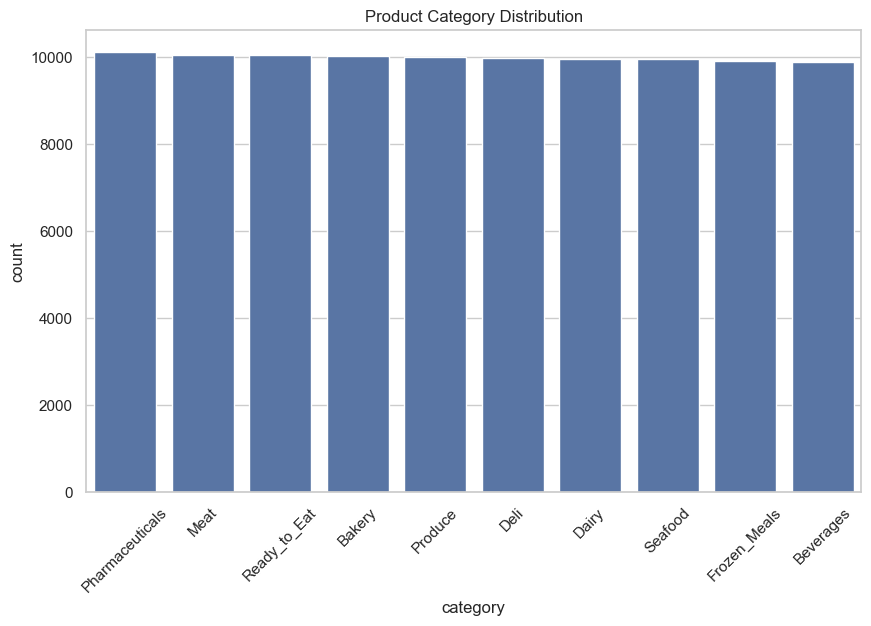

In [16]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='category', order=df['category'].value_counts().index)
plt.title('Product Category Distribution')
plt.xticks(rotation=45)
plt.show()

### Category Distribution Analysis

The dataset contains 10 product categories with nearly equal distribution across records (~10,000 transactions per category).  
This balanced distribution ensures fair comparison across categories during further analysis of revenue, spoilage, and profitability.

In [17]:
category_revenue = df.groupby('category')['revenue'].sum().sort_values(ascending=False)
category_revenue

category
Pharmaceuticals    4.078488e+08
Seafood            4.653028e+07
Meat               2.899504e+07
Deli               2.254278e+07
Ready_to_Eat       1.816300e+07
Frozen_Meals       1.589091e+07
Bakery             1.515875e+07
Dairy              1.477499e+07
Beverages          1.212428e+07
Produce            9.125912e+06
Name: revenue, dtype: float64

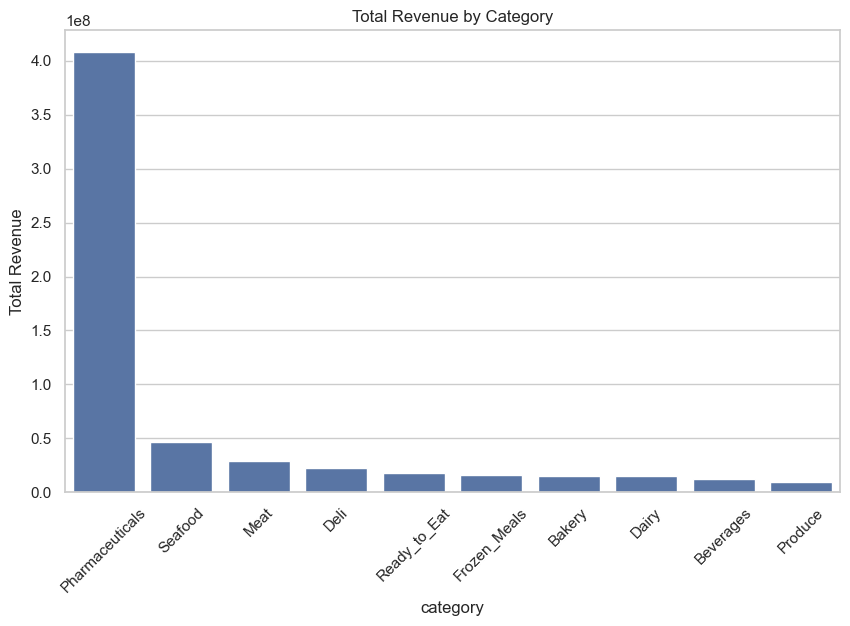

In [18]:
plt.figure(figsize=(10,6))
sns.barplot(x=category_revenue.index, y=category_revenue.values)
plt.title('Total Revenue by Category')
plt.xticks(rotation=45)
plt.ylabel('Total Revenue')
plt.show()

In [19]:
category_price = df.groupby('category')['selling_price'].mean().sort_values(ascending=False)
category_price

category
Pharmaceuticals    251.567488
Seafood             21.897063
Meat                13.433449
Frozen_Meals        11.640193
Deli                10.203832
Ready_to_Eat         8.202522
Bakery               6.950223
Dairy                6.734071
Beverages            5.824638
Produce              4.221467
Name: selling_price, dtype: float64

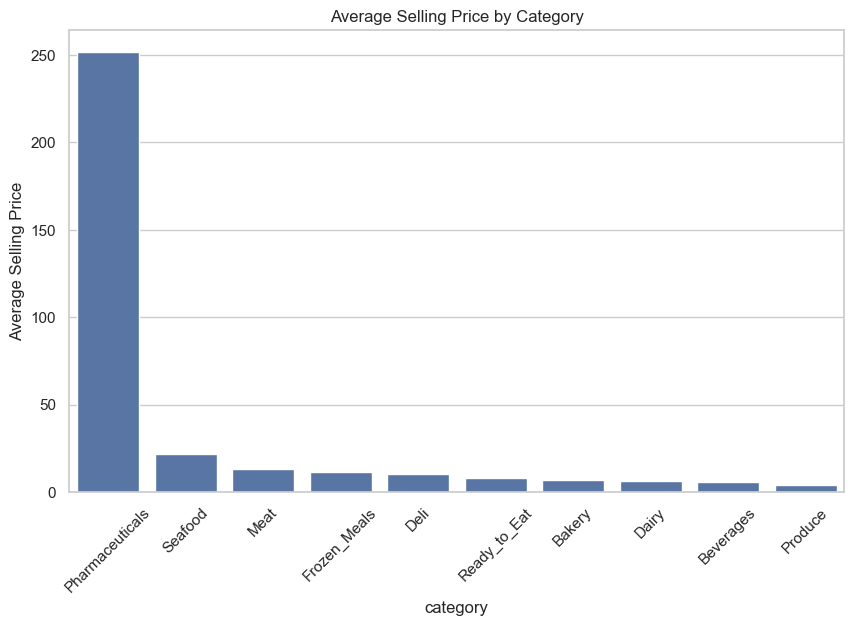

In [20]:
plt.figure(figsize=(10,6))
sns.barplot(x=category_price.index, y=category_price.values)
plt.title('Average Selling Price by Category')
plt.xticks(rotation=45)
plt.ylabel('Average Selling Price')
plt.show()

### Average Selling Price Analysis

Pharmaceutical products have a significantly higher average selling price (~251) compared to all other categories, which range between 4 and 22.

This explains why Pharmaceuticals dominate total revenue. The revenue leadership is primarily price-driven rather than volume-driven.

In [21]:
category_units = df.groupby('category')['units_sold'].sum().sort_values(ascending=False)
category_units

category
Ready_to_Eat       2214133
Dairy              2197001
Deli               2191345
Bakery             2177225
Produce            2154250
Meat               2151323
Seafood            2118652
Beverages          2089959
Pharmaceuticals    1630249
Frozen_Meals       1359428
Name: units_sold, dtype: int64

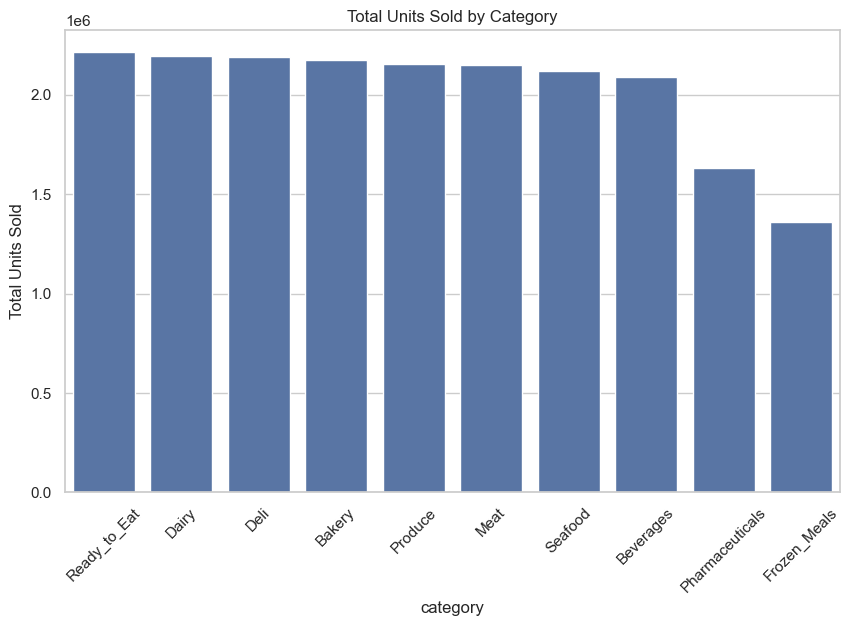

In [22]:
plt.figure(figsize=(10,6))
sns.barplot(x=category_units.index, y=category_units.values)
plt.title('Total Units Sold by Category')
plt.xticks(rotation=45)
plt.ylabel('Total Units Sold')
plt.show()

### Units Sold Analysis

Ready-to-Eat products have the highest total units sold (~2.2 million), indicating strong consumer demand.

Pharmaceuticals, despite generating the highest revenue, have comparatively lower unit sales (~1.6 million). 

This confirms that the revenue dominance of Pharmaceuticals is primarily driven by high pricing rather than high sales volume.

In [23]:
spoilage_rate = df.groupby('category')['was_spoiled'].mean().sort_values(ascending=False) * 100
spoilage_rate

category
Ready_to_Eat       22.111653
Meat               20.954749
Pharmaceuticals    20.701581
Seafood            20.668876
Deli               19.417476
Dairy              18.887997
Produce            18.668133
Bakery             18.278713
Beverages          17.725482
Frozen_Meals       16.940441
Name: was_spoiled, dtype: float64

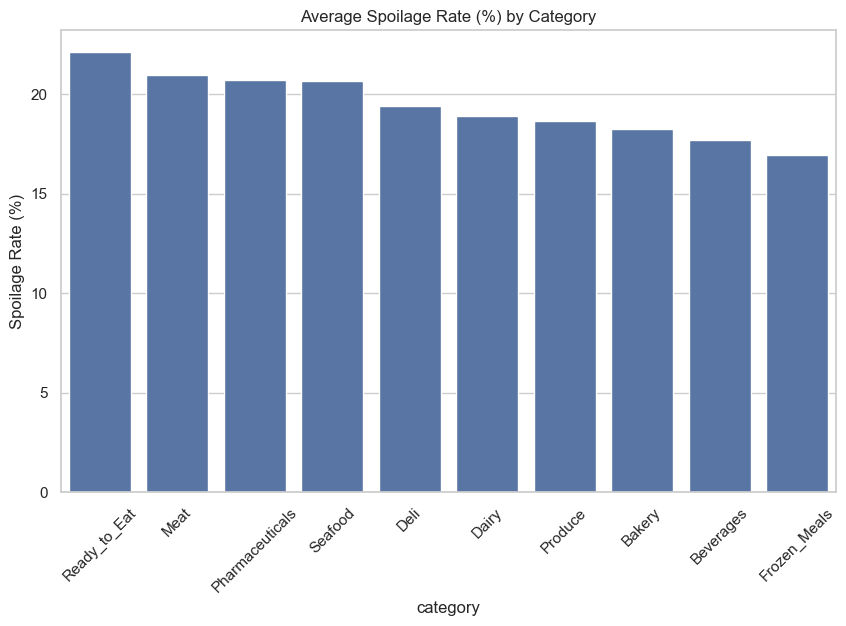

In [24]:
plt.figure(figsize=(10,6))
sns.barplot(x=spoilage_rate.index, y=spoilage_rate.values)
plt.title('Average Spoilage Rate (%) by Category')
plt.xticks(rotation=45)
plt.ylabel('Spoilage Rate (%)')
plt.show()

### Spoilage Rate Analysis by Category

Ready-to-Eat products exhibit the highest spoilage rate (~22%), despite also having the highest unit sales. This indicates high consumer demand but also significant waste risk.

Pharmaceuticals, although the top revenue-generating category, also show a high spoilage rate (~20.7%). Given their high price, spoilage in this category may result in substantial financial losses.

Frozen Meals have the lowest spoilage rate (~16.9%), suggesting better shelf stability and storage efficiency.

In [25]:
category_waste = df.groupby('category')['waste_cost'].sum().sort_values(ascending=False)
category_waste

category
Pharmaceuticals    1.360678e+08
Frozen_Meals       7.675230e+06
Seafood            6.065974e+06
Meat               3.514362e+06
Deli               2.270907e+06
Ready_to_Eat       2.269304e+06
Bakery             1.709072e+06
Beverages          1.383686e+06
Dairy              1.277574e+06
Produce            9.905569e+05
Name: waste_cost, dtype: float64

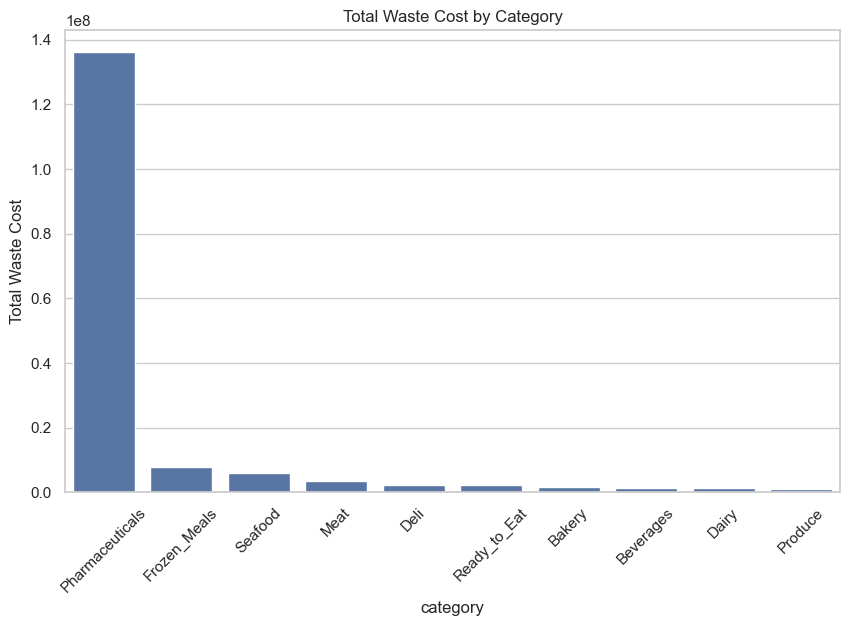

In [26]:
plt.figure(figsize=(10,6))
sns.barplot(x=category_waste.index, y=category_waste.values)
plt.title('Total Waste Cost by Category')
plt.xticks(rotation=45)
plt.ylabel('Total Waste Cost')
plt.show()

### Waste Cost Analysis by Category

Pharmaceuticals incur the highest total waste cost (~136 million), which is significantly higher than all other categories. 

Despite being the top revenue-generating category, Pharmaceuticals also represent the highest financial risk due to spoilage.

This suggests that improving inventory control and storage management for Pharmaceuticals could significantly enhance overall profitability.

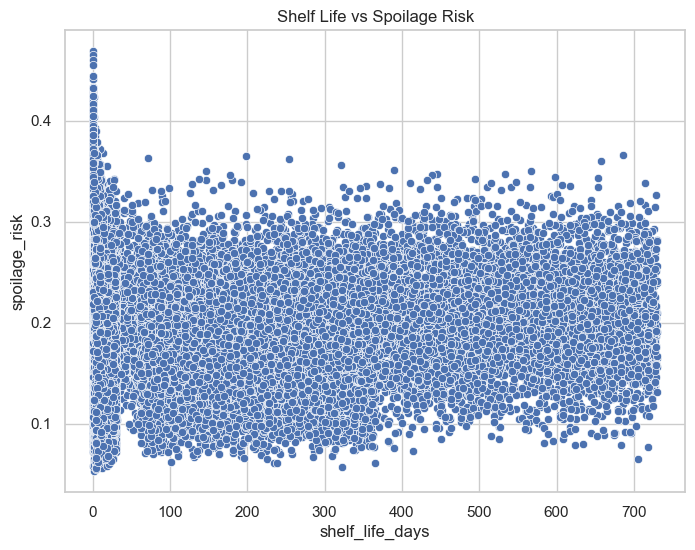

In [27]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='shelf_life_days', y='spoilage_risk')
plt.title('Shelf Life vs Spoilage Risk')
plt.show()

In [28]:
df[['shelf_life_days','spoilage_risk']].corr()

,shelf_life_days,spoilage_risk
shelf_life_days,1.000000,-0.013824
spoilage_risk,-0.013824,1.000000


### Shelf Life vs Spoilage Risk Analysis

The correlation between shelf life and spoilage risk is -0.0138, indicating an extremely weak negative relationship.

This suggests that shelf life alone does not significantly determine spoilage risk. Other factors such as storage temperature, handling quality, or demand variability may have stronger influence on spoilage outcomes.

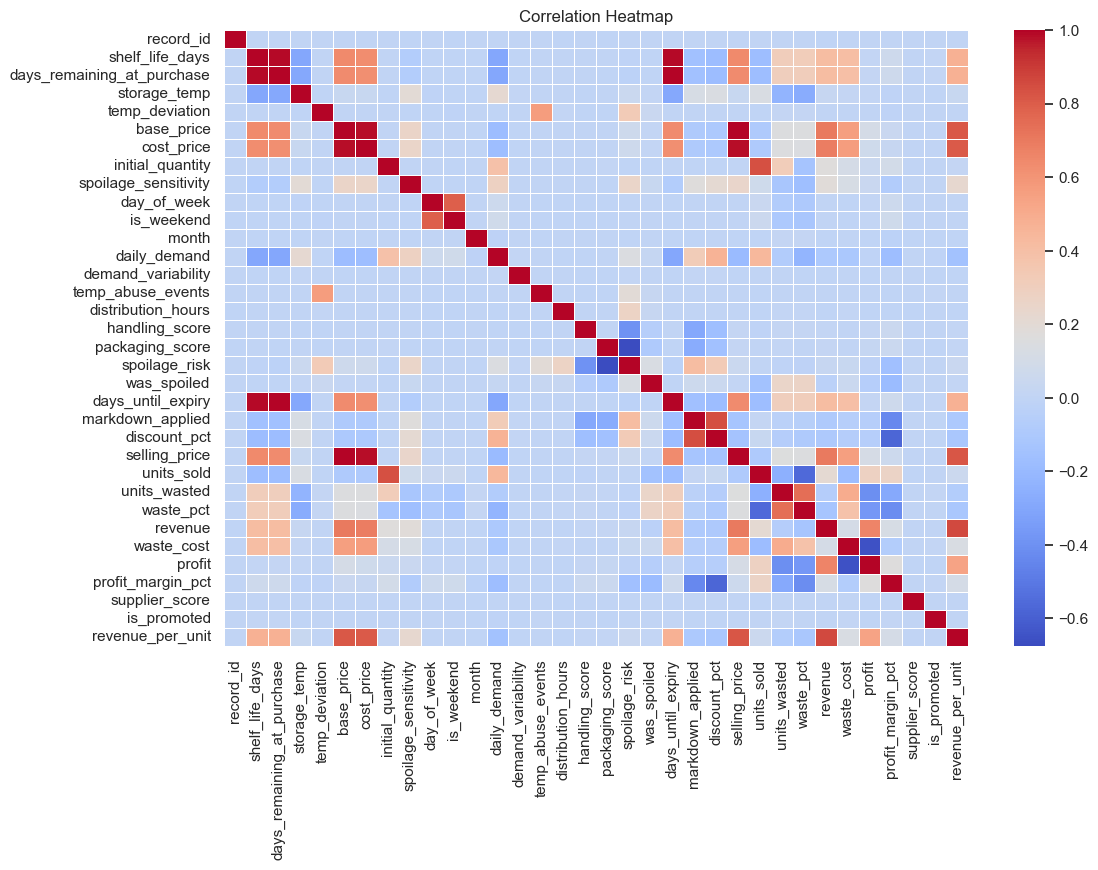

In [29]:
plt.figure(figsize=(12,8))
corr_matrix = df.corr(numeric_only=True)

sns.heatmap(corr_matrix, 
            cmap='coolwarm',
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

### Correlation Heatmap Analysis

The heatmap reveals several strong and meaningful relationships:

- Selling Price is strongly positively correlated with Revenue.
- Units Sold has a strong positive relationship with Revenue.
- Waste Cost is strongly correlated with Units Wasted.
- Profit shows strong positive correlation with Revenue and negative correlation with Waste Cost.

Additionally, Shelf Life shows only a weak relationship with Spoilage Risk, indicating that spoilage is influenced by multiple operational factors rather than shelf life alone.

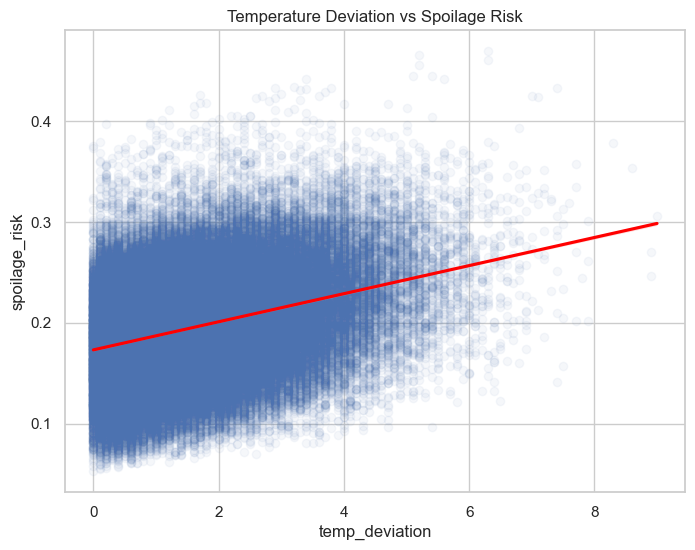

In [30]:
plt.figure(figsize=(8,6))
sns.regplot(data=df, x='temp_deviation', y='spoilage_risk',
            scatter_kws={'alpha':0.05},
            line_kws={'color':'red'})
plt.title('Temperature Deviation vs Spoilage Risk')
plt.show()

In [31]:
df[['temp_deviation','spoilage_risk']].corr()

,temp_deviation,spoilage_risk
temp_deviation,1.000000,0.332139
spoilage_risk,0.332139,1.000000


### Temperature Deviation vs Spoilage Risk

The correlation between temperature deviation and spoilage risk is 0.332, indicating a moderate positive relationship.

This suggests that higher deviations from optimal storage temperature significantly increase the risk of spoilage.

Compared to shelf life (which showed minimal correlation), temperature control appears to be a stronger operational factor influencing spoilage outcomes.

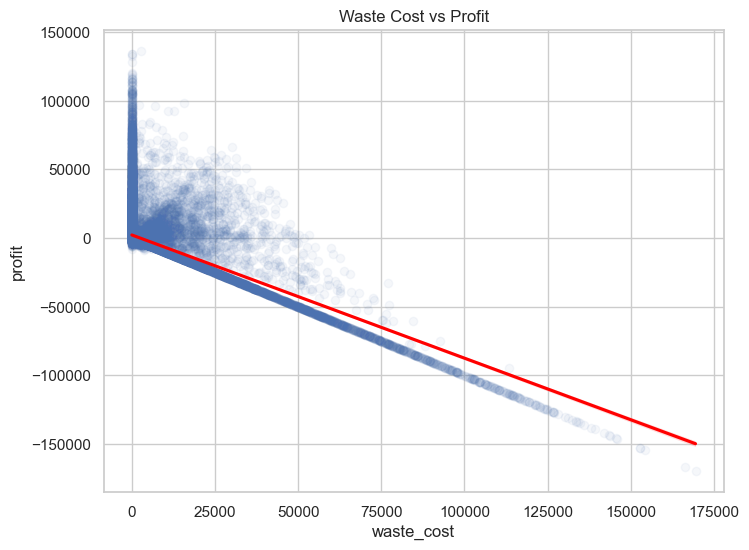

In [37]:
plt.figure(figsize=(8,6))
sns.regplot(data=df, x='waste_cost', y='profit',
            scatter_kws={'alpha':0.05},
            line_kws={'color':'red'})
plt.title('Waste Cost vs Profit')
plt.show()

In [36]:
df[['waste_cost','profit']].corr()

,waste_cost,profit
waste_cost,1.000000,-0.654589
profit,-0.654589,1.000000


### Waste Cost vs Profit Analysis

The correlation between waste cost and profit is -0.6546, indicating a strong negative relationship.

This demonstrates that increased waste directly reduces profitability. Products or categories with high spoilage and waste costs significantly impact overall financial performance.

Effective waste management and improved storage control can therefore substantially enhance profit margins.

## Key Insights

1. Pharmaceuticals generate the highest revenue, primarily driven by high selling prices rather than high sales volume.

2. Ready-to-Eat products have the highest units sold but also exhibit the highest spoilage rate, indicating strong demand but high waste risk.

3. Pharmaceuticals incur the highest total waste cost, making them financially sensitive to spoilage.

4. Shelf life shows negligible correlation with spoilage risk (-0.0138), indicating that shelf duration alone does not determine spoilage outcomes.

5. Temperature deviation has a moderate positive correlation (0.332) with spoilage risk, highlighting the importance of proper storage conditions.

6. Waste cost has a strong negative correlation (-0.6546) with profit, demonstrating that waste reduction directly improves profitability.

## Conclusion

This analysis highlights that revenue optimization in perishable goods management is strongly influenced by operational control factors rather than shelf life alone.

Temperature management plays a significant role in reducing spoilage risk. Additionally, high-value categories such as Pharmaceuticals require tighter inventory and storage control to prevent substantial financial losses.

Overall, reducing waste cost and improving storage efficiency are critical strategies for enhancing profitability in perishable goods management.

## Recommendations

- Implement stricter temperature monitoring systems to minimize spoilage risk.
- Focus inventory control on high-value categories like Pharmaceuticals.
- Optimize demand forecasting for Ready-to-Eat products to reduce overstocking.
- Introduce dynamic discount strategies for products nearing expiration.
- Monitor waste metrics regularly to protect profit margins.